In [ ]:
# Machine learning assignment part 3


In [1]:
# Importing packages - Please DO NOT alter this box ##
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.nn import functional as F
import torch.optim as optim
from torch.utils.data.sampler import WeightedRandomSampler
torch.manual_seed(0)

from captum.attr import IntegratedGradients
from captum.attr import DeepLift
from captum.attr import NoiseTunnel
from captum.attr import visualization as viz

import torchvision
from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter()

import os
import imageio
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm
from scipy.ndimage import binary_erosion
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns

import wandb #comment this out if you are not using weights and biases
import random #comment this out if you are not using weights and biases

# Set device to cuda if it's available otherwise default to "cpu"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [26]:
images = "/projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/species"

In [27]:
# We must turn our images into tensors, resize, and normalize them 
# We can also add additional transformations to images 
transform = transforms.Compose([transforms.ToTensor(), 
                                #We will start with a model called Resnet18 that is optimized for 224x224 images
                                #It is set to a very SMALL size initially so the model will train fast in class
                                transforms.Resize([32,32]),
                                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize the data, these are the values that ResNet suggests based on their training data (natural scences)
                               ])
all_images = datasets.ImageFolder(images, transform)
print(all_images)

Dataset ImageFolder
    Number of datapoints: 2794
    Root location: /projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/species
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=[32, 32], interpolation=bilinear, max_size=None, antialias=True)
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )


In [28]:
all_images = datasets.ImageFolder(images, transform )
print(len(all_images))
print(all_images)

2794
Dataset ImageFolder
    Number of datapoints: 2794
    Root location: /projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/species
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=[32, 32], interpolation=bilinear, max_size=None, antialias=True)
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )


In [29]:
print(all_images.class_to_idx)

{'beluga': 0, 'common_dolphin': 1, 'false_killer_whale': 2, 'fin_whale': 3, 'gray_whale': 4, 'humpback_whale': 5}


In [30]:
def show_random_dataset_image(dataset):
    idx = np.random.randint(0, len(dataset))    # take a random sample
    img, mask = dataset[idx]                    # get the image and the nuclei masks
    f, axarr = plt.subplots(1, 2)               # make two plots on one figure
    axarr[0].imshow(img[0], cmap="viridis")                     # show the image, cmap is the color map that the image is being shown in
    #axarr[1].imshow(mask[0])                    # show the masks
    _ = [ax.axis('off') for ax in axarr]        # remove the axes
    print('Image size is %s' % {img[0].shape})
    print(img.shape)
    plt.show()

Image size is {torch.Size([224, 224])}
torch.Size([3, 224, 224])


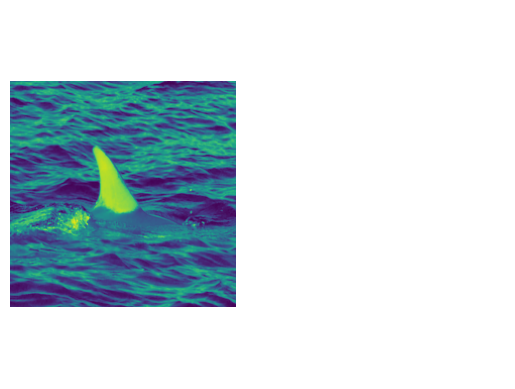

In [31]:
# ADD YOUR TRANSFORMATION HERE
transform = transforms.Compose([
            transforms.Resize([224,224]), # Resize the image as our model is optimized for 224x224 pixels
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]) # Normalize the data, these are the values that ResNet suggests based on their training data (natural scences))

all_images = datasets.ImageFolder(images, transform )
show_random_dataset_image(all_images)

In [32]:
train_size = int(0.7 * len(all_images))
val_size = int(0.15 * len(all_images))
test_size = len(all_images) - (train_size + val_size)
print(train_size, val_size, test_size)
assert train_size + val_size + test_size == len(all_images)

1955 419 420


In [33]:
train_set, val_set, test_set = torch.utils.data.random_split(all_images, [train_size, val_size, test_size])

In [34]:
def _get_weights(subset,full_dataset):
    ys = np.array([y for _, y in subset])
    counts = np.bincount(ys)
    label_weights = 1.0 / counts
    weights = label_weights[ys]

    print("Number of images per class:")
    for c, n, w in zip(full_dataset.classes, counts, label_weights):
        print(f"\t{c}:\tn={n}\tweight={w}")
        
    return weights

In [35]:
train_weights = _get_weights(train_set,all_images)
train_sampler = WeightedRandomSampler(train_weights, len(train_weights))

Number of images per class:
	beluga:	n=456	weight=0.0021929824561403508
	common_dolphin:	n=58	weight=0.017241379310344827
	false_killer_whale:	n=728	weight=0.0013736263736263737
	fin_whale:	n=128	weight=0.0078125
	gray_whale:	n=49	weight=0.02040816326530612
	humpback_whale:	n=536	weight=0.0018656716417910447


In [39]:
batchsize = 88
learning_rate=1e-4
epochs=6

train_loader = DataLoader(train_set, batch_size=batchsize, drop_last=True, sampler=train_sampler)
val_loader = DataLoader(val_set, batch_size=batchsize, drop_last=True, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batchsize, drop_last=True, shuffle=True)

In [40]:
## Model
#########
## First, we create the basic block that will be used in our residual net
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        ## Conv1: convolution layer, batch normalization, ReLU activation
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        ## Conv2: convolution layer, batch normalization
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        ## Shortcut connection: adds input to output
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    # The forward method calls on each layer
    def forward(self, x):
        ## Conv1: convolution layer, batch normalization, ReLU activation
        out = self.conv1(x) 
        out = self.bn1(out)
        out = self.relu(out)
        ## Conv2: convolution layer, batch normalization
        out = self.conv2(out)
        out = self.bn2(out)
        ## Shortcut connection
        out += self.shortcut(x)
        ## Final activation
        out = self.relu(out)
        return out
############
## Next, we put together these building blocks and create our residual net
class ResNet18(nn.Module):
    # specify the number of classes that we are predicting
    def __init__(self, num_classes=6):
        super(ResNet18, self).__init__()
        # In channels = Num pixels in H + Num pixels in W
        self.in_channels = 64
        
        # First convolution set (convolution, batch norm, relu)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # Our building blocks
        # The numbers correspond to the matrix shape
        ### We increase the number of filters/channels (i.e., the first number) as we go
        self.layer1 = self._make_layer(BasicBlock, 64, 2, stride=1)
        self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2)
        self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2)
        self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2)

        # Average pooling 
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Final layer that makes the classification
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        # First convolution set (convolution, batch norm, relu)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        # Our 4 building blocks
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        # Final layer that makes the classification
        out = self.fc(out)
        return out

## Getting our model and transferring it to the GPU
import torchvision.models as models

model = models.resnet18(weights="IMAGENET1K_V1")

#define loss function & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    

Epoch [1/6] | Batch #1 | Batch Accuracy 1.14%
Epoch [1/6] | Batch #2 | Batch Accuracy 3.41%
Epoch [1/6] | Batch #3 | Batch Accuracy 7.95%
Epoch [1/6] | Batch #4 | Batch Accuracy 10.80%
Epoch [1/6] | Batch #5 | Batch Accuracy 17.05%
Epoch [1/6] | Batch #6 | Batch Accuracy 22.54%
Epoch [1/6] | Batch #7 | Batch Accuracy 27.44%
Epoch [1/6] | Batch #8 | Batch Accuracy 30.26%
Epoch [1/6] | Batch #9 | Batch Accuracy 35.10%
Epoch [1/6] | Batch #10 | Batch Accuracy 39.20%
Epoch [1/6] | Batch #11 | Batch Accuracy 43.18%
Epoch [1/6] | Batch #12 | Batch Accuracy 46.78%
Epoch [1/6] | Batch #13 | Batch Accuracy 49.91%
Epoch [1/6] | Batch #14 | Batch Accuracy 52.44%
Epoch [1/6] | Batch #15 | Batch Accuracy 54.85%
Epoch [1/6] | Batch #16 | Batch Accuracy 56.68%
Epoch [1/6] | Batch #17 | Batch Accuracy 58.69%
Epoch [1/6] | Batch #18 | Batch Accuracy 60.61%
Epoch [1/6] | Batch #19 | Batch Accuracy 62.02%
Epoch [1/6] | Batch #20 | Batch Accuracy 63.35%
Epoch [1/6] | Batch #21 | Batch Accuracy 64.88%
Epoc

train_loss,█▁▁▁▁▁
validation_accuracy,▁▇▇▇██
validation_loss,█▂▂▁▁▁
train_loss,0.0047
validation_accuracy,99.43182
validation_loss,0.05317


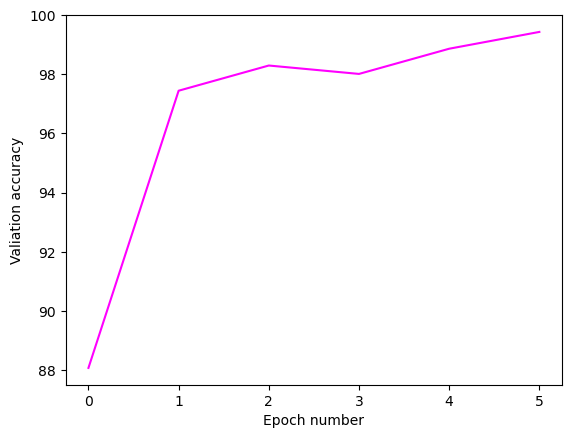

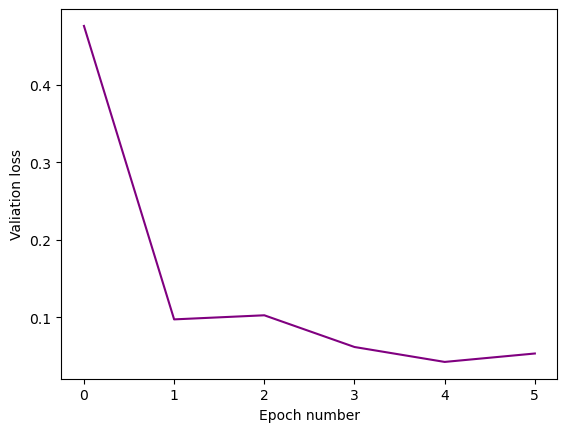

NameError: name 'predict' is not defined

In [41]:
wandb.init(
    project="BGMP_HappyWhale",
    name="amandaaaa-HappyWhale-part3_run7", ##update this with your name
    config={"learning rate":.0001, # possibly update
        "architecture": "CNN",
        "dataset": "Species",
        "epochs": 6, "batch_size":88}  # possibly update
) 
batch=0
num_epochs = epochs
train_losses, train_acc_list, val_losses, val_acc_list = [], [], [],[]


for epoch in range(num_epochs):
    # Setting model to "training mode"
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    # For each batch of data within the loader
    for inputs, labels in train_loader:
        # Send our input images and their labels to the GPU
        inputs, labels = inputs.to(device), labels.to(device)
        # Zero the gradients
        optimizer.zero_grad()
        # Inputting our training images into the model
        # and Predicting the image classification label
        outputs = model(inputs)
        # Figuring out the loss from our predictions
        loss = criterion(outputs, labels)
        # Compute gradients (aka backward pass)
        loss.backward()
        # Update model parameters
        optimizer.step()

        # Adding the loss to our running sum
        # Loss is calculated for each batch within an epoch
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        batch+=1
        print(f'Epoch [{epoch+1}/{num_epochs}] | Batch #{batch} | Batch Accuracy {(correct/total)*100:.2f}%')
 # Getting metrics for our training pass 
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_acc_list.append(train_acc)
    
    # Switching our model to "evaluation mode"
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    # Disable gradient calculation b/c we are evalulating the model
    with torch.no_grad():
        # Load in batches of our validation data
        for inputs, labels in val_loader:
            # Send test images and labels to the GPU
            inputs, labels = inputs.to(device), labels.to(device)
            # Predict the image classification label
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            # Figuring out how many predicted labels = true labels
            correct += predicted.eq(labels).sum().item()

            # Figuring out the loss from our predictions
            loss = criterion(outputs, labels)
            # Adding the loss to our running sum
            # Loss is calculated for each batch within an epoch
            running_loss += loss.item() * inputs.size(0)
    # Getting our accuracy from our test data
    val_acc = 100. * correct / total
    val_acc_list.append(val_acc)
    # Getting the loss from our test data
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.2f}%')

    # log metrics to wandb
    wandb.log({"validation_accuracy": val_acc, "validation_loss": val_loss, "train_loss":train_loss})

wandb.finish()


plt.plot(range(epochs), val_acc_list, color = "magenta")
plt.xlabel("Epoch number")
plt.ylabel("Valiation accuracy")
plt.show()  

plt.plot(range(epochs), val_losses, color = "purple")
plt.xlabel("Epoch number")
plt.ylabel("Valiation loss")
plt.show()  

y_pred, y_true = predict(model, test_set)
cm_analysis(y_true, y_pred, "Confusion matrix")

In [15]:
print("epochs =", epochs)
print("len(train_losses) =", len(train_losses))
print("len(val_acc_list) =", len(val_acc_list))
print("first val acc =", val_acc_list[0] if len(val_acc_list)>0 else None)
print("last  val acc =", val_acc_list[-1] if len(val_acc_list)>0 else None)

epochs = 4
len(train_losses) = 4
len(val_acc_list) = 4
first val acc = 95.75
last  val acc = 96.25
